# Credit Risk Modelling
**Dataset:** 20,000 loan applications  
**Target:** `LoanApproved` (Binary Classification)  
**Split Strategy:** 70:30 Train-Test with 5-Fold Cross Validation  
**Models:** XGBoost, Random Forest, LightGBM, Gradient Boosting

## 1. Importing Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# Advanced Models
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier

# Optional: CatBoost (install if not present)
# try:
#     from catboost import CatBoostClassifier
#     CATBOOST_AVAILABLE = True
# except ImportError:
#     print('CatBoost not installed. Run: pip install catboost')
#     CATBOOST_AVAILABLE = False

# Imbalanced learning
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    print('imbalanced-learn not installed. Run: pip install imbalanced-learn')
    SMOTE_AVAILABLE = False

import joblib
import os
import json

# Display settings
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42
print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Loading & Inspecting Data

In [3]:

FILE_PATH = '/Users/muditpanwar/PycharmProjects/credit_risk_analysis_project/data/loan_data_new.xlsx'   # or .csv

if FILE_PATH.endswith('.xlsx'):
    df = pd.read_excel(FILE_PATH, parse_dates=['ApplicationDate'])
else:
    df = pd.read_csv(FILE_PATH, parse_dates=['ApplicationDate'])

print(f'Dataset shape: {df.shape}')
print(f'\nColumn dtypes:\n{df.dtypes}')

Dataset shape: (20000, 51)

Column dtypes:
Unnamed: 0                             int64
ApplicationDate               datetime64[ns]
Age                                    int64
AnnualIncome                           int64
CreditScore                            int64
EmploymentStatus                      object
EducationLevel                        object
Experience                             int64
LoanAmount                             int64
LoanDuration                           int64
MaritalStatus                         object
NumberOfDependents                     int64
HomeOwnershipStatus                   object
MonthlyDebtPayments                    int64
CreditCardUtilizationRate            float64
NumberOfOpenCreditLines                int64
NumberOfCreditInquiries                int64
DebtToIncomeRatio                    float64
BankruptcyHistory                      int64
LoanPurpose                           object
PreviousLoanDefaults                   int64
PaymentHisto

In [4]:
df.head(3)

,Unnamed: 0,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore,App_Month,App_Quarter,MonthlyObligations,ResidualIncome,Income_Stability,Credit_Tier,Risk_Band,DTI_Bucket,Risk_Segment,ApplicationStatus,Income_Bracket,AgeGroup,Repayment_Status,Purpose_Default_Rate
0,0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,2,Own,183,0.3544,1,2,0.3583,0,Home,0,29,9,7632,1202,146111,19183,3329.0000,0.7250,11,126928,0.1997,0.2276,419.8060,0.1811,0,49.0000,2018-01,2018Q1,602.8060,2726.1940,Stable,2. Fair,High Risk,Moderate (30-40%),Normal,Rejected,Low,Middle-Aged,Good Repayer,0.0942
1,1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.0878,5,3,0.3303,0,Debt Consolidation,0,21,9,4627,3460,53204,9595,3309.0833,0.9351,3,43609,0.2070,0.2011,794.0542,0.3899,0,52.0000,2018-01,2018Q1,1290.0542,2019.0291,Stable,2. Fair,High Risk,Moderate (30-40%),Normal,Rejected,Low,Middle-Aged,Good Repayer,0.1022
2,2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,2,Rent,902,0.1374,2,0,0.2447,0,Education,0,20,22,886,895,25176,128874,3393.6667,0.8722,6,5205,0.2176,0.2125,666.4067,0.4622,0,52.0000,2018-01,2018Q1,1568.4067,1825.2600,Stable,1. Poor,High Risk,Healthy (<30%),Low Risk (Prime),Rejected,Low,Senior,Good Repayer,0.1024


In [5]:
# Basic info
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values!')
print('\n=== Target Distribution ===')
print(df['LoanApproved'].value_counts())
print(f'\nApproval Rate: {df["LoanApproved"].mean()*100:.2f}%')

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 51 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Unnamed: 0                  20000 non-null  int64         
 1   ApplicationDate             20000 non-null  datetime64[ns]
 2   Age                         20000 non-null  int64         
 3   AnnualIncome                20000 non-null  int64         
 4   CreditScore                 20000 non-null  int64         
 5   EmploymentStatus            20000 non-null  object        
 6   EducationLevel              20000 non-null  object        
 7   Experience                  20000 non-null  int64         
 8   LoanAmount                  20000 non-null  int64         
 9   LoanDuration                20000 non-null  int64         
 10  MaritalStatus               20000 non-null  object        
 11  NumberOfDependents          20000

In [6]:
df.describe()

,Unnamed: 0,ApplicationDate,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore,MonthlyObligations,ResidualIncome,Purpose_Default_Rate
count,20000.0000,20000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000
mean,9999.5000,2045-05-18 12:00:00,39.7526,59161.4736,571.6124,17.5227,24882.8678,54.0570,1.5173,454.2927,0.2864,3.0234,0.9930,0.2857,0.0524,0.1001,23.9936,14.9573,4946.0522,1782.5551,96964.3955,36252.4128,4930.1228,0.7999,5.0027,72294.3188,0.2391,0.2391,911.6071,0.4022,0.2390,50.7668,1365.8998,3564.2230,0.1001
min,0.0000,2018-01-01 00:00:00,18.0000,15000.0000,343.0000,0.0000,3674.0000,12.0000,0.0000,50.0000,0.0010,0.0000,0.0000,0.0017,0.0000,0.0000,8.0000,1.0000,73.0000,24.0000,2098.0000,372.0000,1250.0000,0.2592,0.0000,1000.0000,0.1301,0.1133,97.0302,0.0160,0.0000,28.8000,230.9929,-8174.1295,0.0942
25%,4999.7500,2031-09-09 18:00:00,32.0000,31679.0000,540.0000,9.0000,15575.0000,36.0000,0.0000,286.0000,0.1608,2.0000,0.0000,0.1610,0.0000,0.0000,21.0000,8.0000,1541.7500,551.0000,31180.2500,11196.7500,2639.9167,0.7274,3.0000,8734.7500,0.2139,0.2091,493.7637,0.1797,0.0000,46.0000,909.3039,1285.0167,0.0942
50%,9999.5000,2045-05-18 12:00:00,40.0000,48566.0000,578.0000,17.0000,21914.5000,48.0000,1.0000,402.0000,0.2667,3.0000,1.0000,0.2645,0.0000,0.0000,24.0000,15.0000,2986.0000,1116.0000,60699.0000,22203.0000,4047.1667,0.8210,5.0000,32855.5000,0.2362,0.2354,728.5115,0.3027,0.0000,52.0000,1194.3688,2737.0491,0.1022
75%,14999.2500,2059-01-25 06:00:00,48.0000,74391.0000,609.0000,25.0000,30835.0000,72.0000,2.0000,564.0000,0.3906,4.0000,2.0000,0.3903,0.0000,0.0000,27.0000,22.0000,5873.2500,2126.0000,117405.2500,43146.5000,6199.2500,0.8923,6.0000,88825.5000,0.2615,0.2655,1112.7708,0.5092,0.0000,56.0000,1621.4697,4899.7525,0.1024
max,19999.0000,2072-10-03 00:00:00,80.0000,485341.0000,712.0000,61.0000,184732.0000,120.0000,5.0000,2919.0000,0.9174,13.0000,7.0000,0.9023,1.0000,1.0000,45.0000,29.0000,200089.0000,52572.0000,2619627.0000,1417302.0000,40445.0833,0.9994,16.0000,2603208.0000,0.4050,0.4468,10892.6295,4.6477,1.0000,84.0000,11478.6295,39043.1692,0.1087
std,5773.6470,NaN,11.6227,40350.8452,50.9974,11.3168,13427.4212,24.6649,1.3863,240.5076,0.1598,1.7362,0.9870,0.1602,0.2228,0.3001,4.9454,8.3716,6604.8875,2245.3788,120799.9392,47251.5109,3362.5704,0.1207,2.2368,117920.0214,0.0355,0.0422,674.5835,0.3389,0.4265,7.7783,720.2459,3441.9339,0.0044


## 3. Exploratory Data Analysis (EDA)

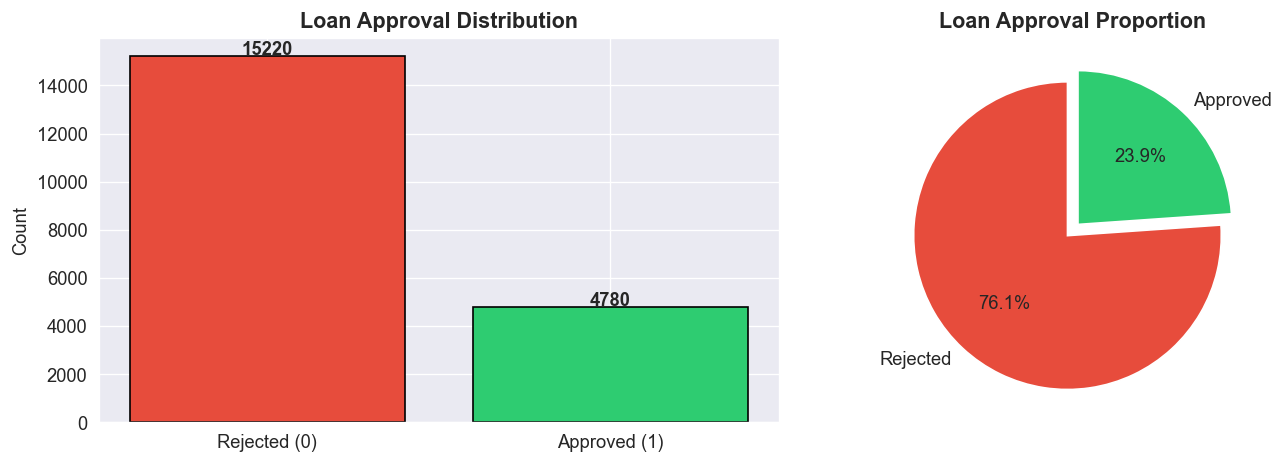

In [9]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['LoanApproved'].value_counts()
axes[0].bar(['Rejected (0)', 'Approved (1)'], counts.values,
            color=['#E74C3C', '#2ECC71'], edgecolor='black')
axes[0].set_title('Loan Approval Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Rejected', 'Approved'],
            autopct='%1.1f%%', colors=['#E74C3C', '#2ECC71'],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Loan Approval Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/muditpanwar/PycharmProjects/credit_risk_analysis_project/output/figures/target_distribution.png', bbox_inches='tight')
plt.show()

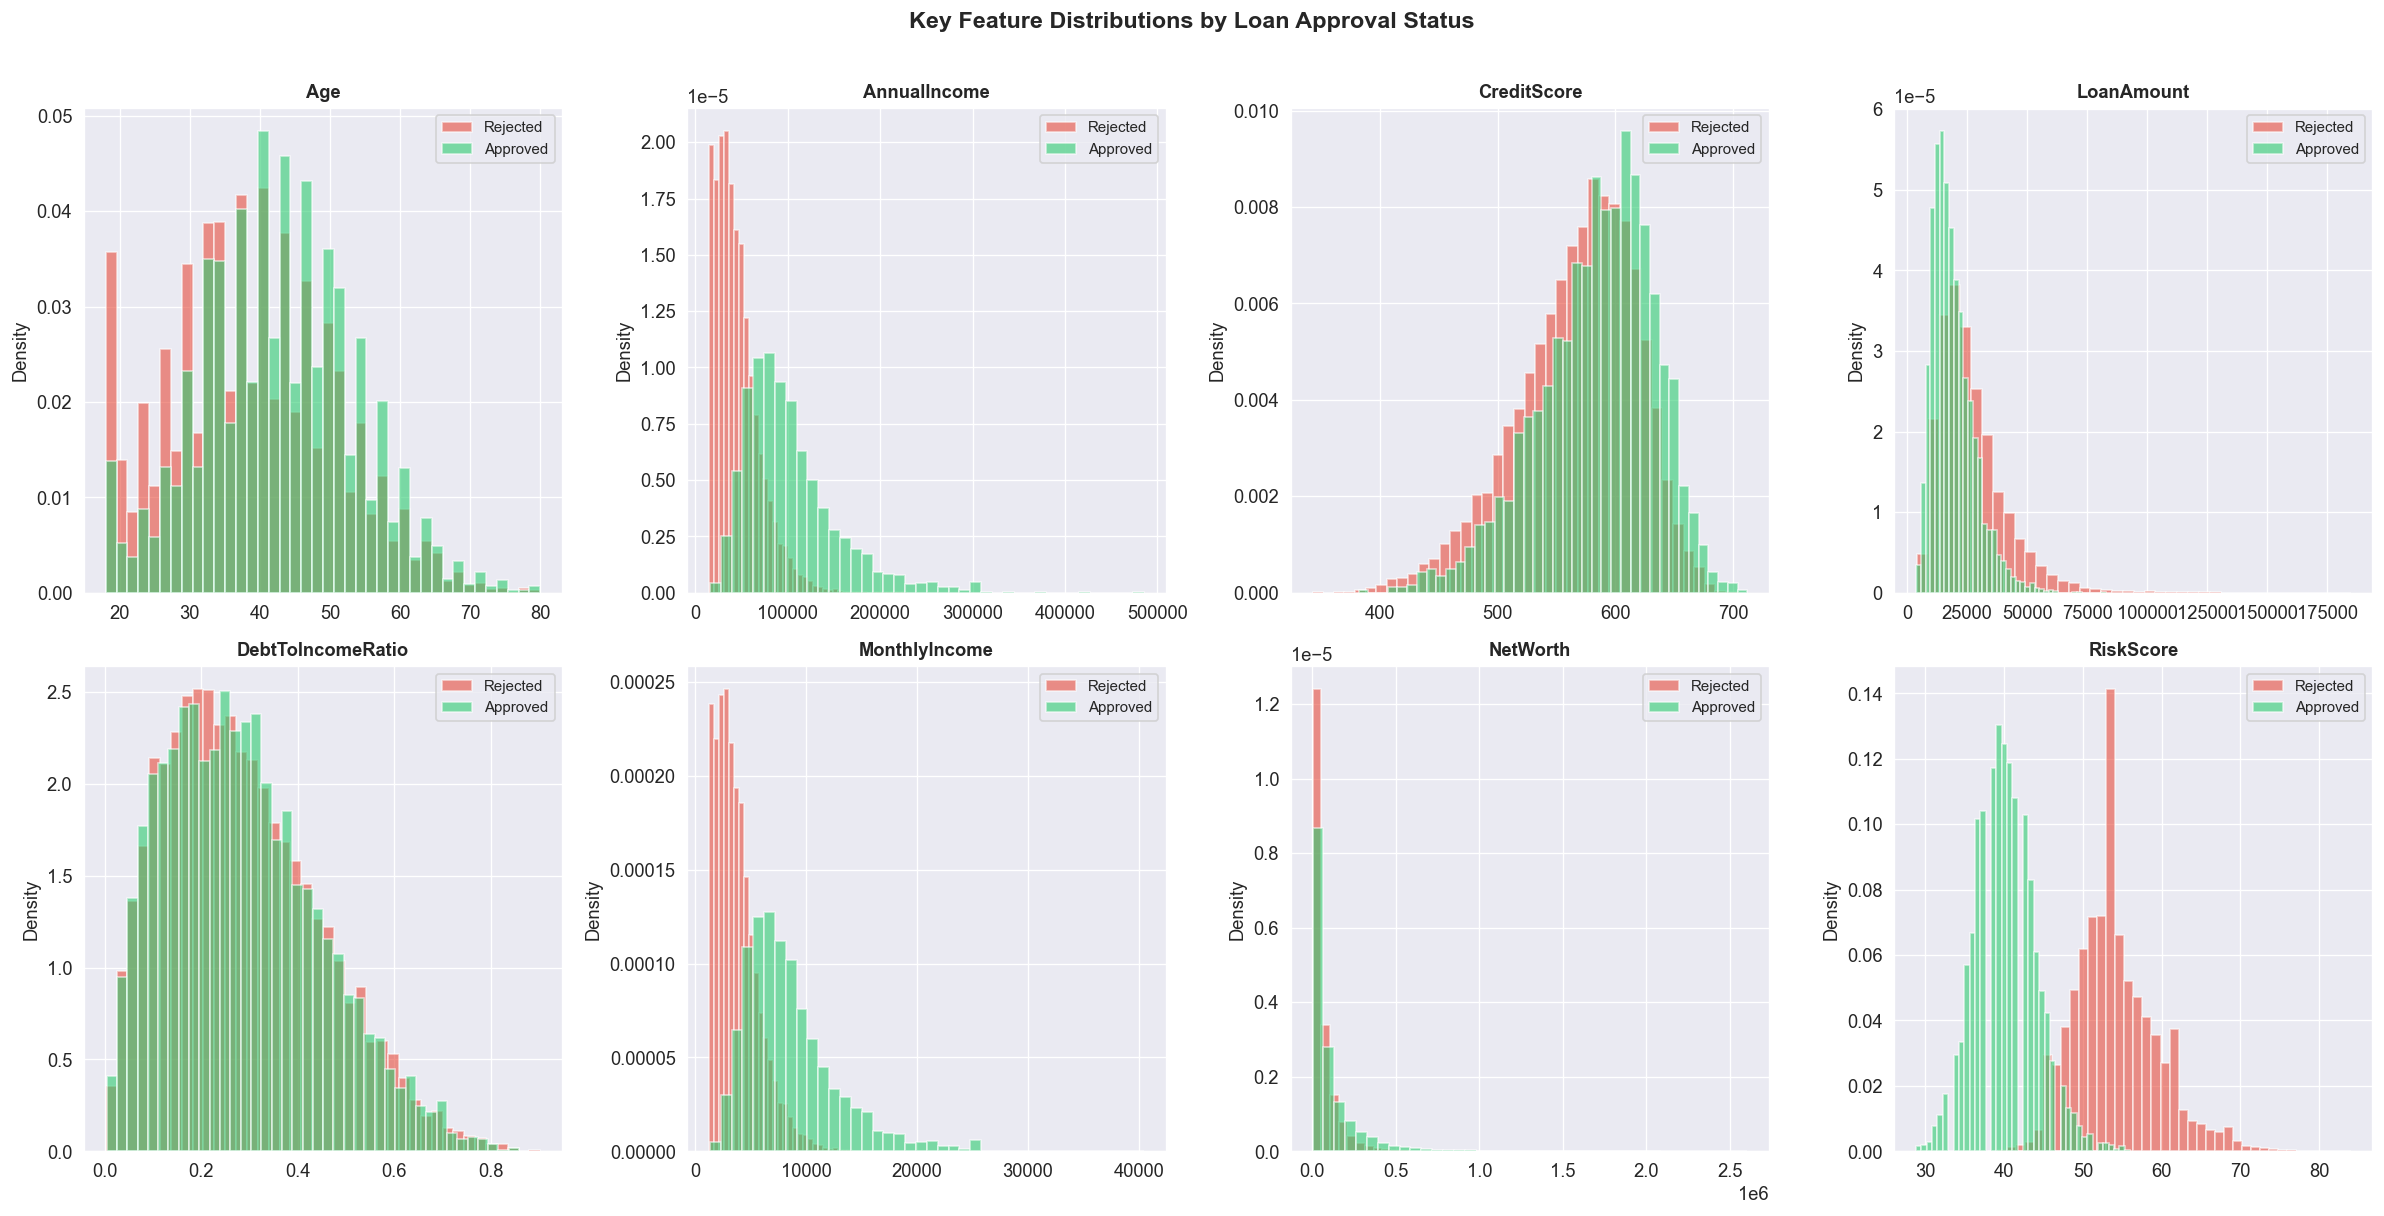

In [10]:
# Key numeric features distribution by approval status
numeric_features = ['Age', 'AnnualIncome', 'CreditScore', 'LoanAmount',
                    'DebtToIncomeRatio', 'MonthlyIncome', 'NetWorth', 'RiskScore']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    for status, color, label in [(0, '#E74C3C', 'Rejected'), (1, '#2ECC71', 'Approved')]:
        axes[i].hist(df[df['LoanApproved'] == status][col].dropna(),
                     bins=40, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].set_ylabel('Density')

plt.suptitle('Key Feature Distributions by Loan Approval Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/Users/muditpanwar/PycharmProjects/credit_risk_analysis_project/output/figures/feature_distributions.png', bbox_inches='tight')
plt.show()

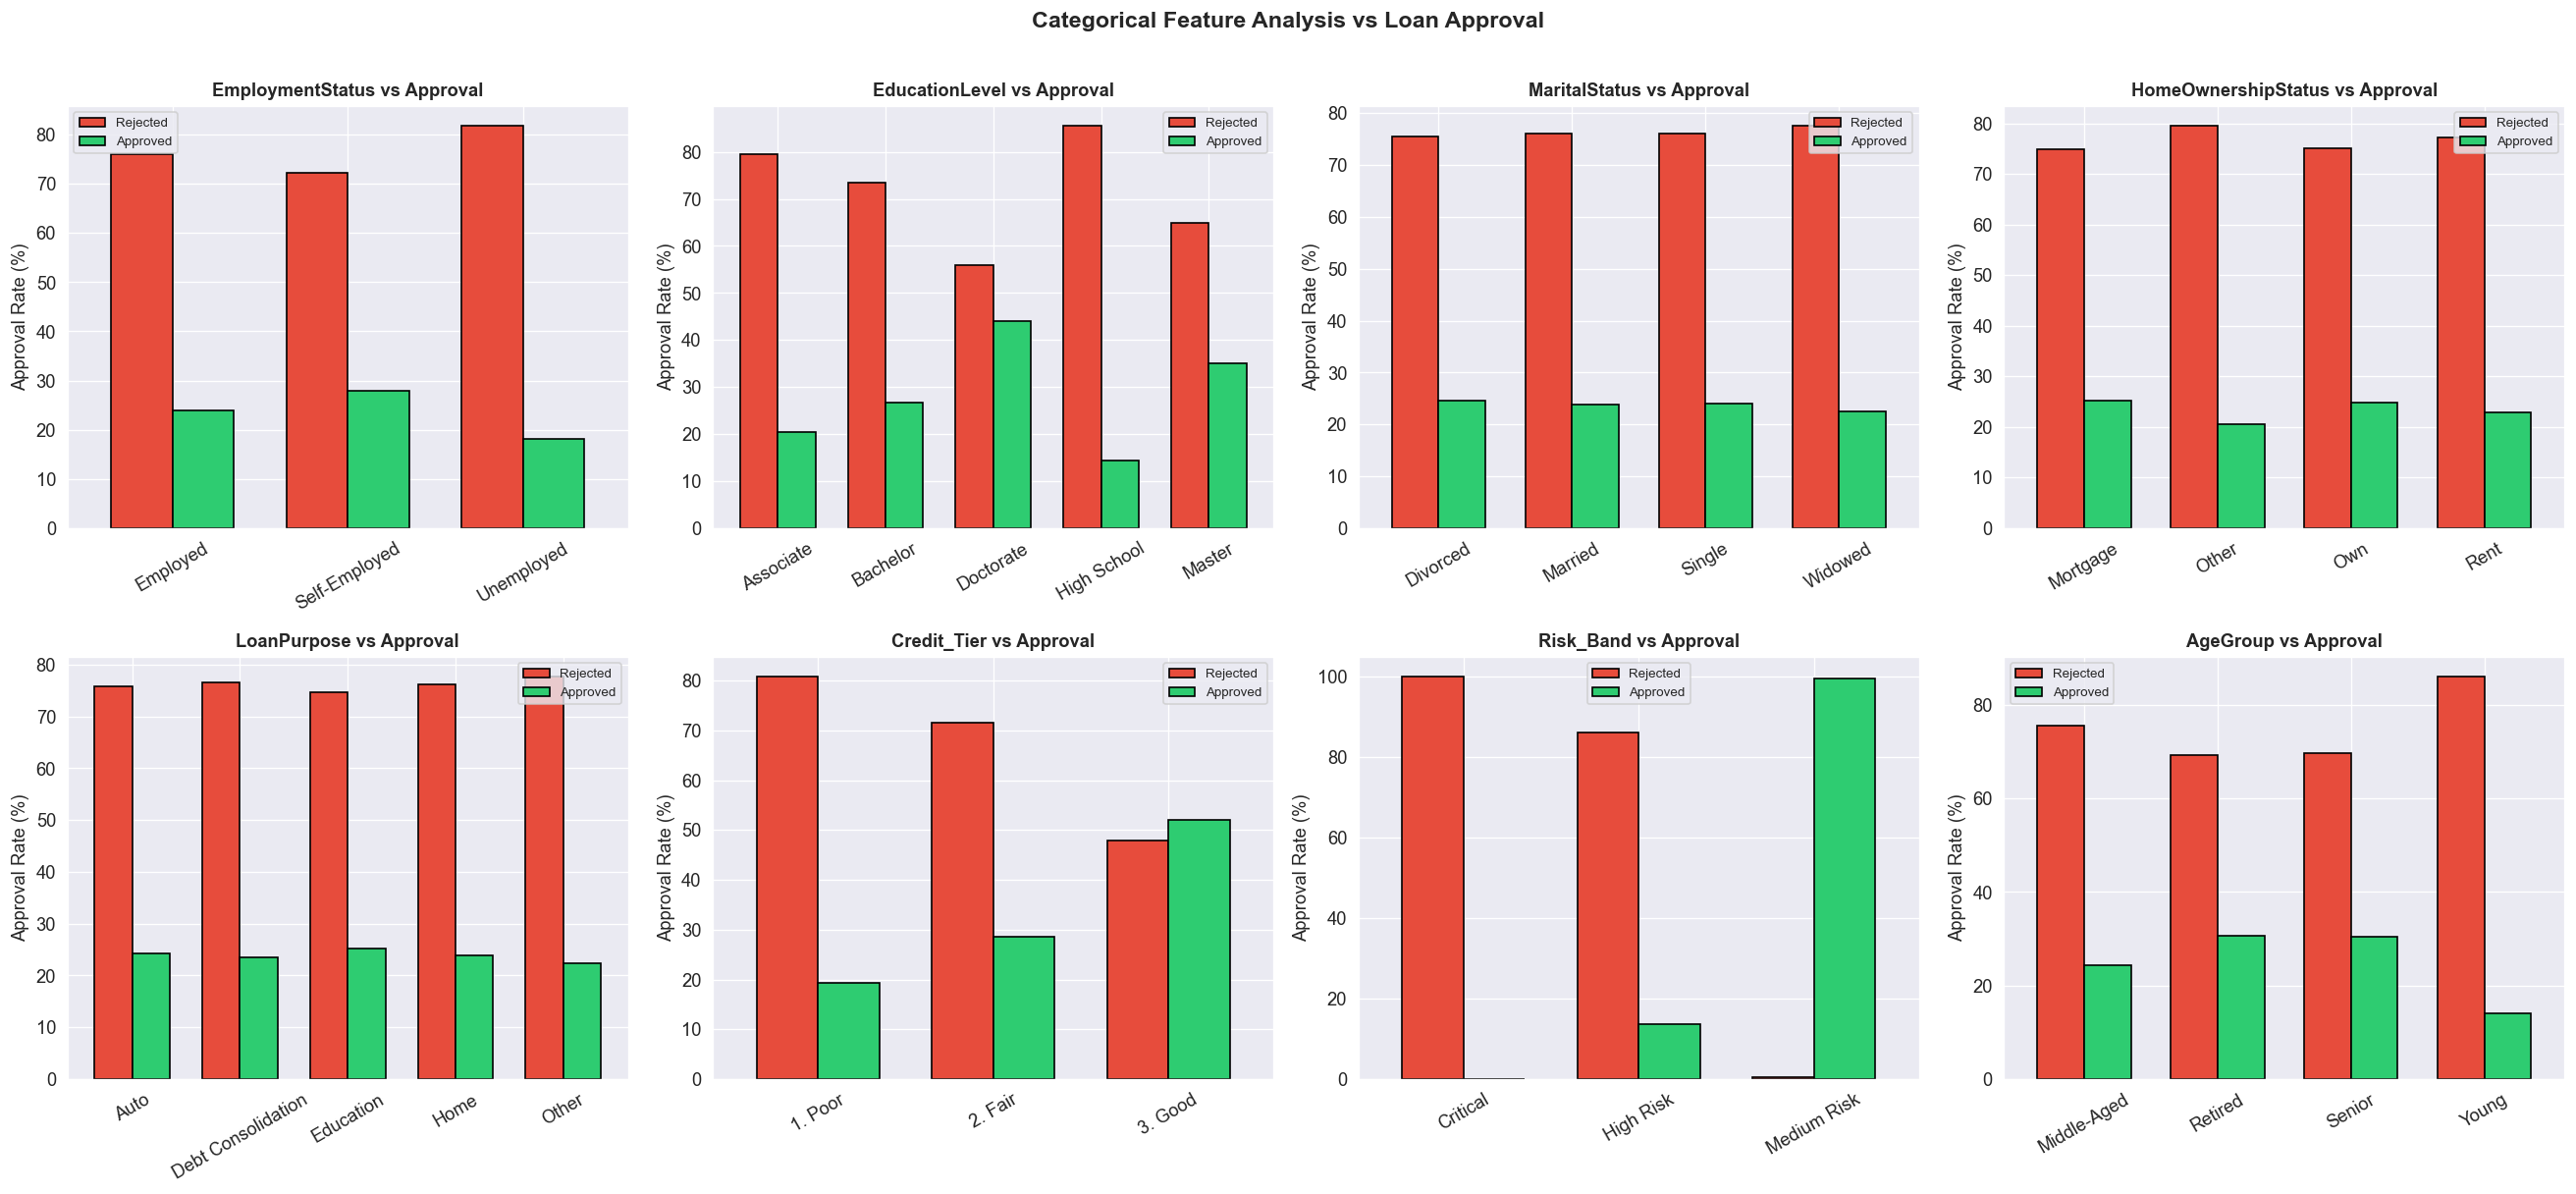

In [11]:
# Categorical features vs Loan Approval
cat_features = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus',
                'HomeOwnershipStatus', 'LoanPurpose', 'Credit_Tier', 'Risk_Band', 'AgeGroup']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    if col in df.columns:
        ct = pd.crosstab(df[col], df['LoanApproved'], normalize='index') * 100
        ct.plot(kind='bar', ax=axes[i], color=['#E74C3C', '#2ECC71'],
                edgecolor='black', width=0.7)
        axes[i].set_title(f'{col} vs Approval', fontsize=11, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Approval Rate (%)')
        axes[i].legend(['Rejected', 'Approved'], fontsize=8)
        axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Categorical Feature Analysis vs Loan Approval', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/Users/muditpanwar/PycharmProjects/credit_risk_analysis_project/output/figures/categorical_analysis.png', bbox_inches='tight')
plt.show()

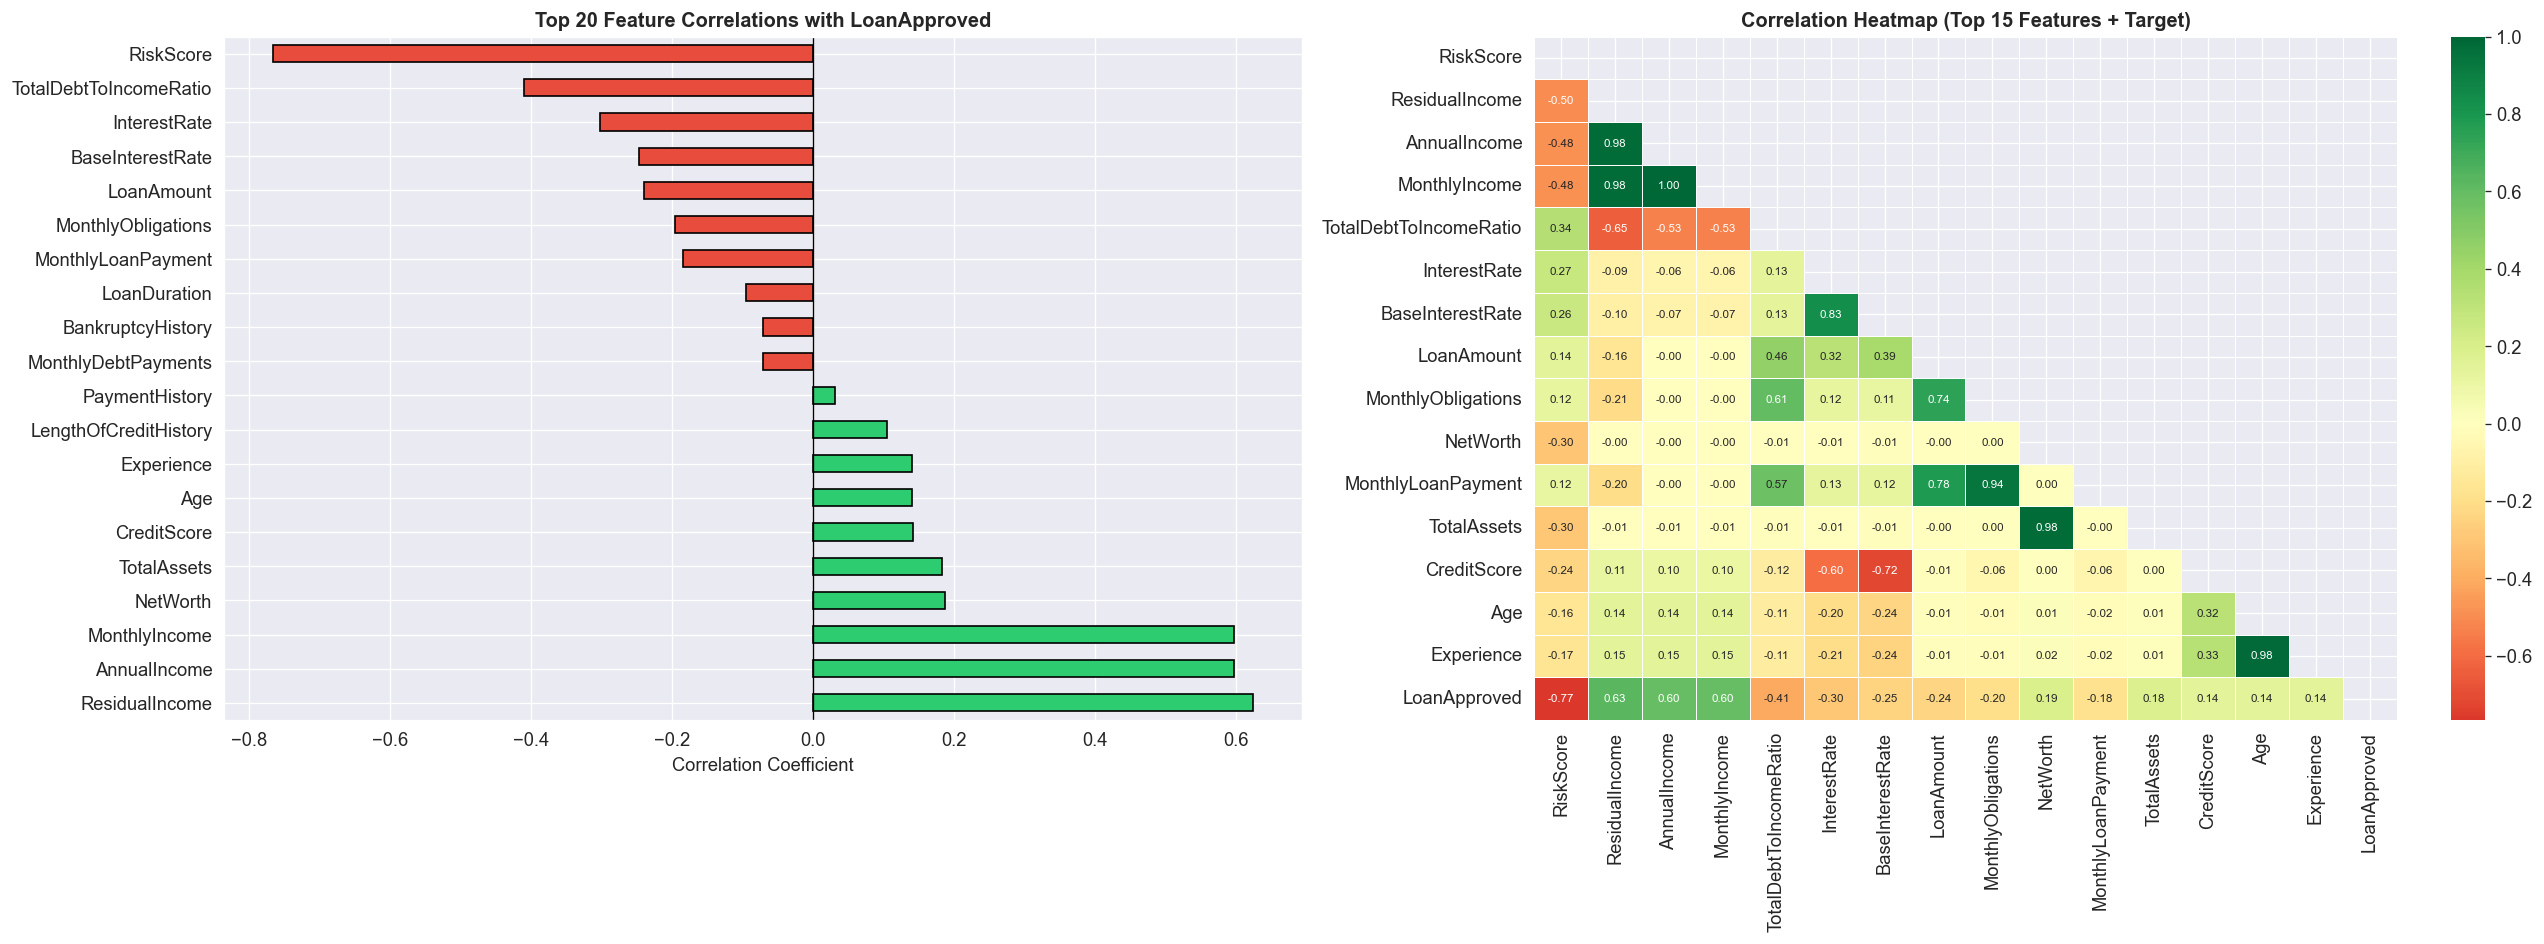

In [12]:
# Correlation heatmap for numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

# Focus on correlation with target
target_corr = corr_matrix['LoanApproved'].drop('LoanApproved').sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Top 20 correlations with target
top_corr = target_corr.head(10).tolist() + target_corr.tail(10).tolist()
top_corr_series = pd.concat([target_corr.head(10), target_corr.tail(10)])
colors = ['#2ECC71' if v > 0 else '#E74C3C' for v in top_corr_series.values]
top_corr_series.plot(kind='barh', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Top 20 Feature Correlations with LoanApproved', fontsize=12, fontweight='bold')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Correlation Coefficient')

# Full heatmap (top 20 by abs correlation)
top_cols = target_corr.abs().nlargest(15).index.tolist() + ['LoanApproved']
corr_sub = df[top_cols].corr()
mask = np.triu(np.ones_like(corr_sub, dtype=bool))
sns.heatmap(corr_sub, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[1], linewidths=0.5, annot_kws={'size': 7})
axes[1].set_title('Correlation Heatmap (Top 15 Features + Target)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/muditpanwar/PycharmProjects/credit_risk_analysis_project/output/figures/correlation_analysis.png', bbox_inches='tight')
plt.show()

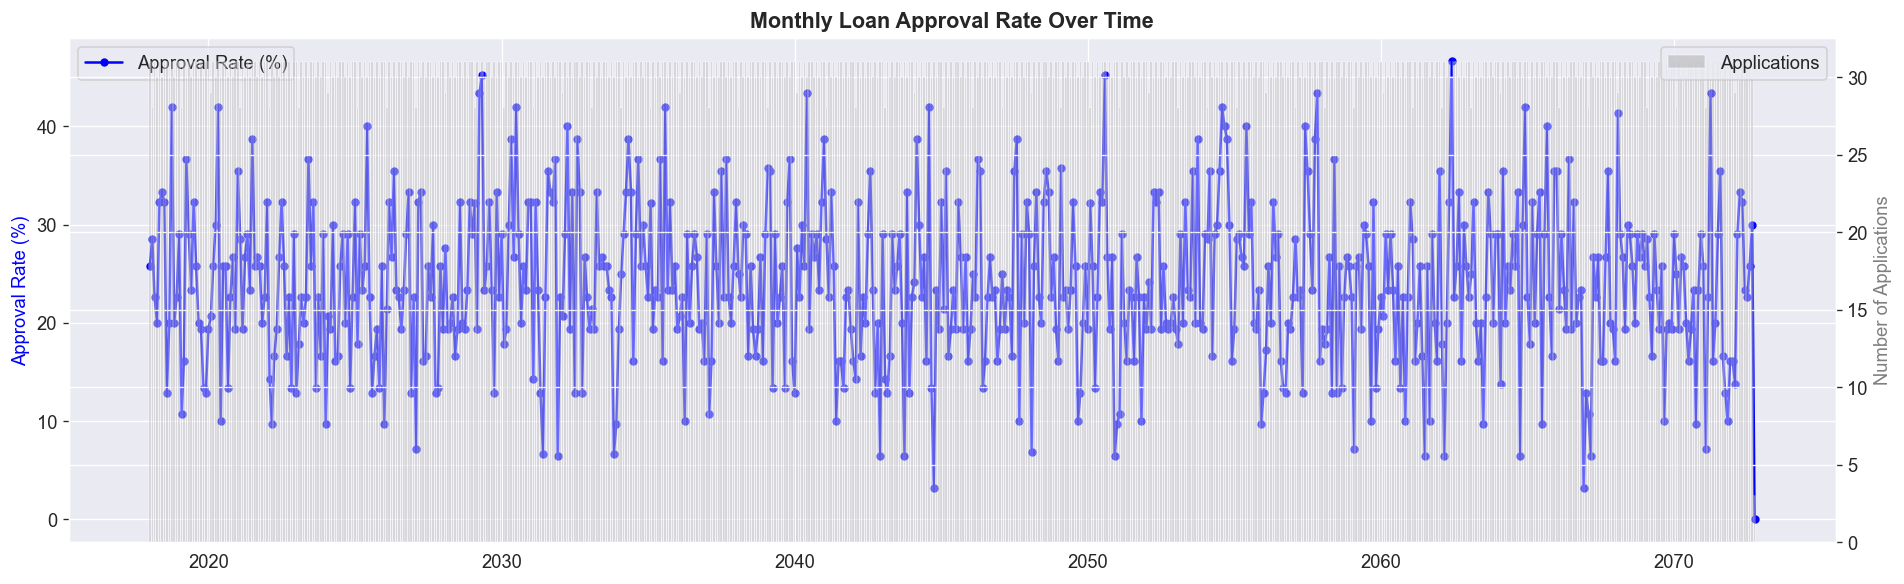

In [13]:
# Time series trend - Monthly approval rate
if 'ApplicationDate' in df.columns:
    monthly = df.groupby('App_Month')['LoanApproved'].agg(['mean', 'count']).reset_index()
    monthly['App_Month'] = pd.to_datetime(monthly['App_Month'])
    monthly = monthly.sort_values('App_Month')

    fig, ax1 = plt.subplots(figsize=(16, 5))
    ax2 = ax1.twinx()

    ax1.plot(monthly['App_Month'], monthly['mean'] * 100, 'b-o', markersize=4, label='Approval Rate (%)')
    ax2.bar(monthly['App_Month'], monthly['count'], alpha=0.3, color='gray', width=20, label='Applications')

    ax1.set_ylabel('Approval Rate (%)', color='blue')
    ax2.set_ylabel('Number of Applications', color='gray')
    ax1.set_title('Monthly Loan Approval Rate Over Time', fontsize=13, fontweight='bold')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('/Users/muditpanwar/PycharmProjects/credit_risk_analysis_project/output/figures/monthly_trend.png', bbox_inches='tight')
    plt.show()

## 4. Feature Engineering & Column Selection

In [14]:

COLS_TO_DROP = [
    'ApplicationDate',    # datetime, already decomposed
    'App_Month',          # too granular date feature
    'ApplicationStatus',  # LEAKAGE - derived from target
    'Repayment_Status',   # LEAKAGE - post-approval behavior
    'InterestRate',       # LEAKAGE - determined post-approval
    'MonthlyLoanPayment', # LEAKAGE - calculated post-approval
    'RiskScore',
]

print('Columns to drop:', COLS_TO_DROP)

df_model = df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns], errors='ignore')
print(f'\nShape after dropping leakage/redundant cols: {df_model.shape}')

Columns to drop: ['ApplicationDate', 'App_Month', 'ApplicationStatus', 'Repayment_Status', 'InterestRate', 'MonthlyLoanPayment', 'RiskScore']

Shape after dropping leakage/redundant cols: (20000, 44)


In [15]:
# ENCODE CATEGORICAL FEATURES

TARGET = 'LoanApproved'

cat_cols = df_model.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

# Ordinal mappings for ordered categories
ordinal_maps = {
    'EducationLevel': {'High School': 0, 'Associate': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4},
    'Credit_Tier': {'1. Poor': 0, '2. Fair': 1, '3. Good': 2, '4. Very Good': 3, '5. Excellent': 4},
    'Risk_Band': {'Low Risk': 0, 'Medium Risk': 1, 'High Risk': 2},
    'Income_Bracket': {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3},
    'DTI_Bucket': {'Healthy (<30%)': 0, 'Moderate (30-40%)': 1, 'High (40-50%)': 2, 'Very High (>50%)': 3},
    'AgeGroup': {'Young Adult': 0, 'Adult': 1, 'Middle-Aged': 2, 'Senior': 3},
    'App_Quarter': {'2018Q1': 0, '2018Q2': 1, '2018Q3': 2, '2018Q4': 3,
                    '2019Q1': 4, '2019Q2': 5, '2019Q3': 6, '2019Q4': 7,
                    '2020Q1': 8, '2020Q2': 9, '2020Q3': 10, '2020Q4': 11,
                    '2021Q1': 12, '2021Q2': 13, '2021Q3': 14, '2021Q4': 15,
                    '2022Q1': 16, '2022Q2': 17, '2022Q3': 18, '2022Q4': 19}
}

df_encoded = df_model.copy()

for col, mapping in ordinal_maps.items():
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].map(mapping).fillna(-1).astype(int)
        print(f'  Ordinal encoded: {col}')

# Label encode remaining categoricals
remaining_cats = df_encoded.select_dtypes(include=['object', 'category']).columns.tolist()
remaining_cats = [c for c in remaining_cats if c != TARGET]

label_encoders = {}
for col in remaining_cats:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f'  Label encoded: {col}')

print(f'\nFinal shape: {df_encoded.shape}')
print(f'All numeric: {df_encoded.select_dtypes(include=[np.number]).shape[1] == df_encoded.shape[1]}')

Categorical columns (13): ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'App_Quarter', 'Income_Stability', 'Credit_Tier', 'Risk_Band', 'DTI_Bucket', 'Risk_Segment', 'Income_Bracket', 'AgeGroup']
  Ordinal encoded: EducationLevel
  Ordinal encoded: Credit_Tier
  Ordinal encoded: Risk_Band
  Ordinal encoded: Income_Bracket
  Ordinal encoded: DTI_Bucket
  Ordinal encoded: AgeGroup
  Ordinal encoded: App_Quarter
  Label encoded: EmploymentStatus
  Label encoded: MaritalStatus
  Label encoded: HomeOwnershipStatus
  Label encoded: LoanPurpose
  Label encoded: Income_Stability
  Label encoded: Risk_Segment

Final shape: (20000, 44)
All numeric: True


In [16]:
# Feature matrix and target
X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

print(f'Feature matrix X: {X.shape}')
print(f'Target y: {y.shape}')
print(f'\nClass distribution:\n{y.value_counts()}')
print(f'\nClass balance: {y.mean()*100:.1f}% positive')

Feature matrix X: (20000, 43)
Target y: (20000,)

Class distribution:
LoanApproved
0    15220
1     4780
Name: count, dtype: int64

Class balance: 23.9% positive


## 5. Train-Test Split (70:30)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print(f'Train size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test size:  {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nTrain class balance: {y_train.mean()*100:.2f}% positive')
print(f'Test class balance:  {y_test.mean()*100:.2f}% positive')

# Handle class imbalance with SMOTE (on training set only)
if SMOTE_AVAILABLE and y_train.value_counts().min() / y_train.value_counts().max() < 0.4:
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print(f'\nAfter SMOTE resampling:')
    print(f'  Train size: {X_train_res.shape[0]}')
    print(f'  Class balance: {pd.Series(y_train_res).value_counts().to_dict()}')
else:
    X_train_res, y_train_res = X_train, y_train
    print('\nSMOTE not applied (classes sufficiently balanced or library unavailable)')

# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('\n5-Fold Stratified Cross-Validation configured.')

Train size: 14000 (70.0%)
Test size:  6000 (30.0%)

Train class balance: 23.90% positive
Test class balance:  23.90% positive

After SMOTE resampling:
  Train size: 21308
  Class balance: {0: 10654, 1: 10654}

5-Fold Stratified Cross-Validation configured.


## 6. Helper Functions

In [20]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name, cv_strategy):
    """Evaluate model with comprehensive metrics."""
    # Cross-validation on training set
    cv_roc = cross_val_score(model, X_tr, y_tr, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
    cv_f1  = cross_val_score(model, X_tr, y_tr, cv=cv_strategy, scoring='f1', n_jobs=-1)
    cv_acc = cross_val_score(model, X_tr, y_tr, cv=cv_strategy, scoring='accuracy', n_jobs=-1)

    # Fit and predict on test
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    metrics = {
        'Model': model_name,
        'CV_ROC_AUC_Mean': cv_roc.mean(),
        'CV_ROC_AUC_Std': cv_roc.std(),
        'CV_F1_Mean': cv_f1.mean(),
        'CV_Accuracy_Mean': cv_acc.mean(),
        'Test_Accuracy': accuracy_score(y_te, y_pred),
        'Test_Precision': precision_score(y_te, y_pred, zero_division=0),
        'Test_Recall': recall_score(y_te, y_pred, zero_division=0),
        'Test_F1': f1_score(y_te, y_pred, zero_division=0),
        'Test_ROC_AUC': roc_auc_score(y_te, y_prob),
        'Test_Avg_Precision': average_precision_score(y_te, y_prob),
    }
    return metrics, y_pred, y_prob


def plot_model_evaluation(model_name, y_test, y_pred, y_prob, save=True):
    """Plot confusion matrix + ROC + PR curve."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
    axes[0].set_title(f'{model_name}\nConfusion Matrix', fontweight='bold')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc_val:.4f}')
    axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1)
    axes[1].fill_between(fpr, tpr, alpha=0.1, color='blue')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{model_name}\nROC Curve', fontweight='bold')
    axes[1].legend()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[2].plot(recall, precision, 'g-', linewidth=2, label=f'AP = {ap:.4f}')
    axes[2].fill_between(recall, precision, alpha=0.1, color='green')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].set_title(f'{model_name}\nPrecision-Recall Curve', fontweight='bold')
    axes[2].legend()

    plt.tight_layout()
    if save:
        fname = f'{model_name.lower().replace(" ", "_")}_eval.png'
        plt.savefig(fname, bbox_inches='tight')
    plt.show()


print('Helper functions defined.')

Helper functions defined.


## 7. Model Training & Hyperparameter Tuning

### 7.1 XGBoost

=== XGBoost Hyperparameter Tuning ===
Fitting 5 folds for each of 128 candidates, totalling 640 fits

Best Params: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 400, 'subsample': 0.8}
Best CV ROC-AUC: 0.9969


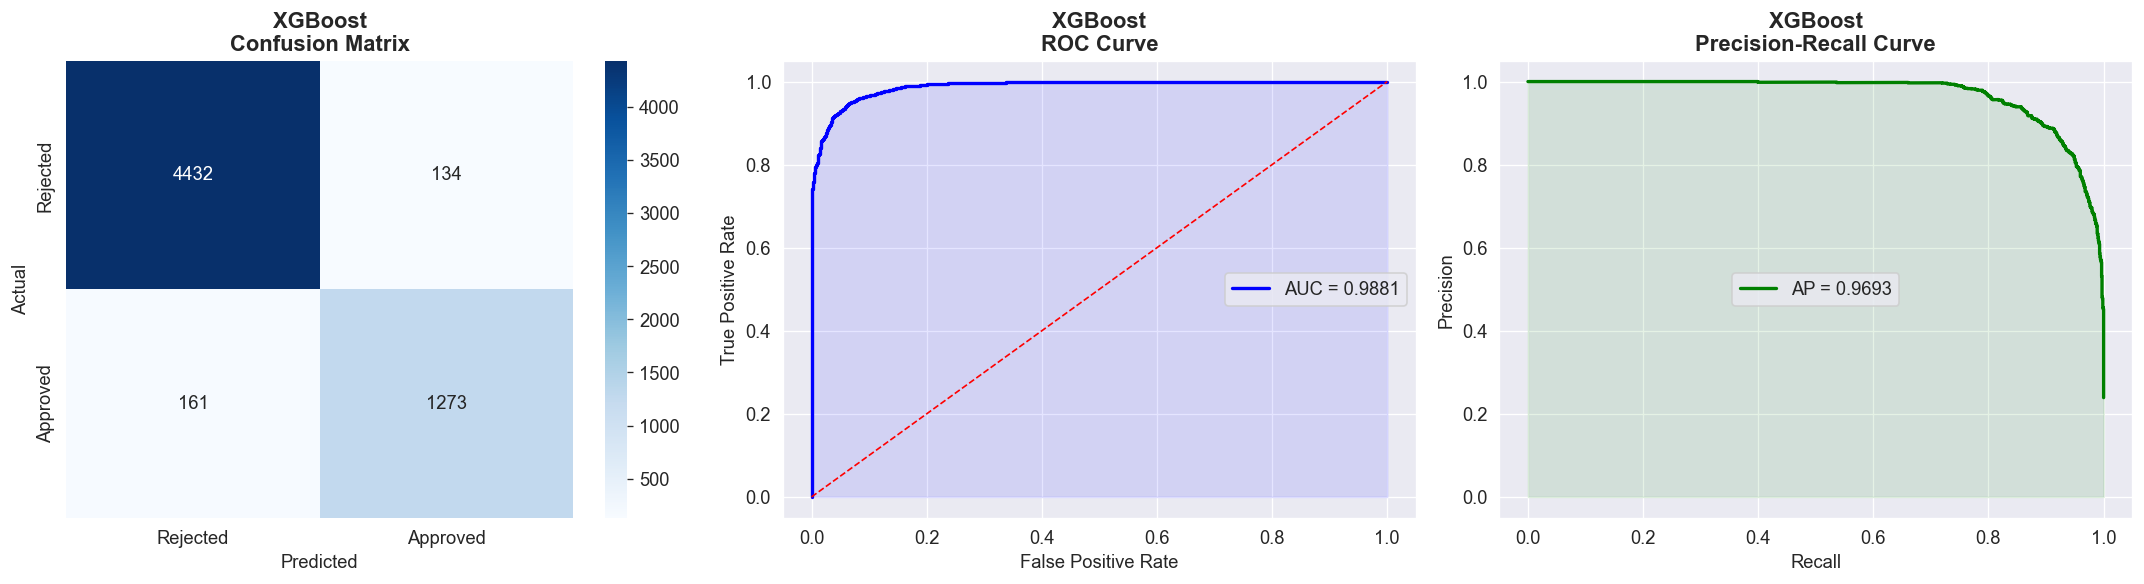


Classification Report:
              precision    recall  f1-score   support

    Rejected       0.96      0.97      0.97      4566
    Approved       0.90      0.89      0.90      1434

    accuracy                           0.95      6000
   macro avg       0.93      0.93      0.93      6000
weighted avg       0.95      0.95      0.95      6000



In [22]:
print('=== XGBoost Hyperparameter Tuning ===')
scale_pos_weight = (y_train_res == 0).sum() / (y_train_res == 1).sum()

xgb_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3],
    'gamma': [0, 0.1]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_grid = GridSearchCV(
    xgb_base, xgb_param_grid, cv=cv,
    scoring='roc_auc', n_jobs=-1, verbose=1, refit=True
)
xgb_grid.fit(X_train_res, y_train_res)

print(f'\nBest Params: {xgb_grid.best_params_}')
print(f'Best CV ROC-AUC: {xgb_grid.best_score_:.4f}')

xgb_best = xgb_grid.best_estimator_
xgb_metrics, xgb_pred, xgb_prob = evaluate_model(
    xgb_best, X_train_res, y_train_res, X_test, y_test, 'XGBoost', cv
)
plot_model_evaluation('XGBoost', y_test, xgb_pred, xgb_prob)
print('\nClassification Report:')
print(classification_report(y_test, xgb_pred, target_names=['Rejected', 'Approved']))

### 7.2 Random Forest

=== Random Forest Hyperparameter Tuning ===
Fitting 5 folds for each of 96 candidates, totalling 480 fits

Best Params: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Best CV ROC-AUC: 0.9950


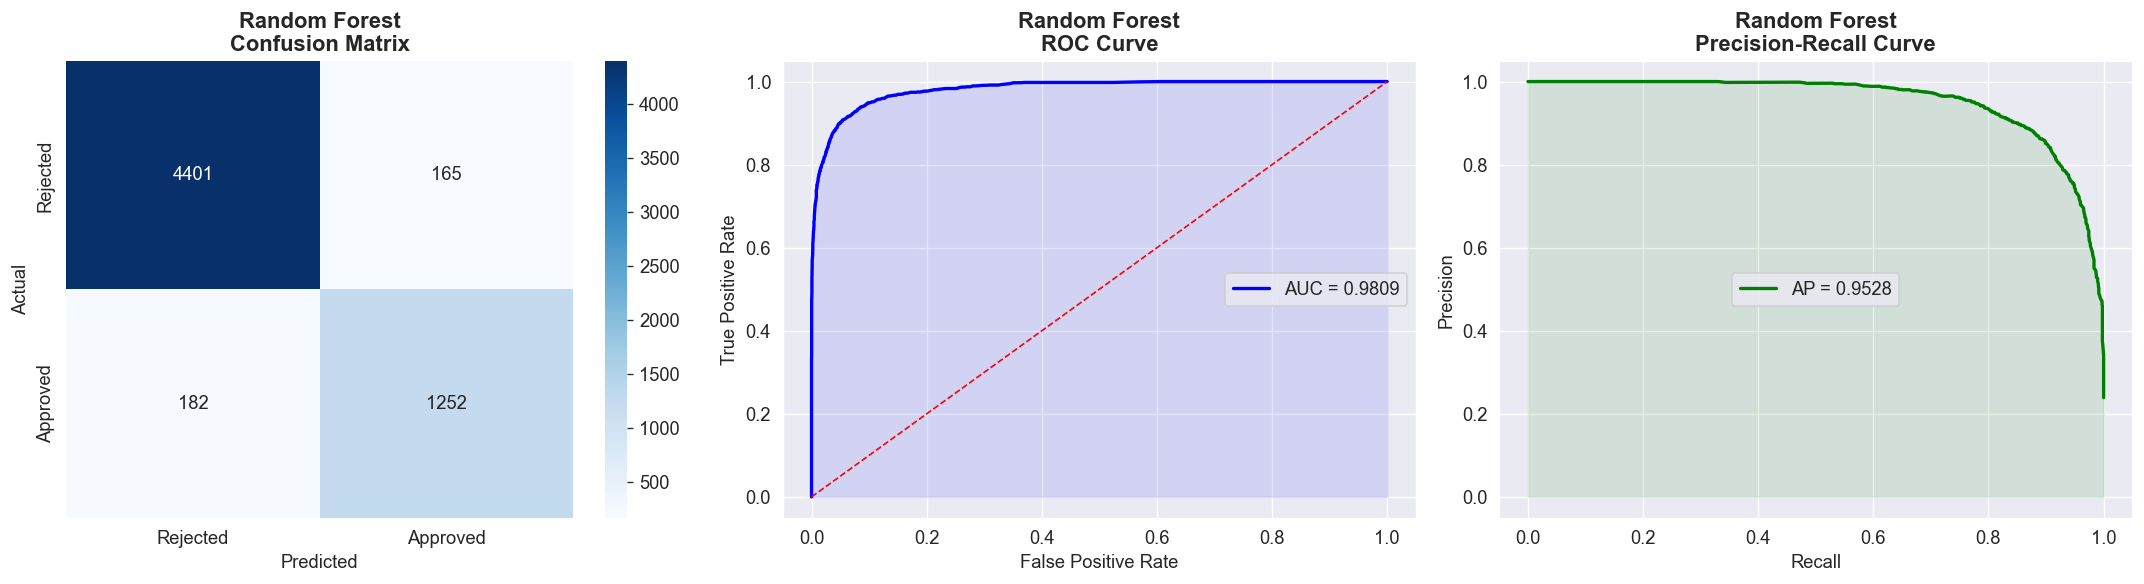


Classification Report:
              precision    recall  f1-score   support

    Rejected       0.96      0.96      0.96      4566
    Approved       0.88      0.87      0.88      1434

    accuracy                           0.94      6000
   macro avg       0.92      0.92      0.92      6000
weighted avg       0.94      0.94      0.94      6000



In [23]:
print('=== Random Forest Hyperparameter Tuning ===')

rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 15, 25],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', None]
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

rf_grid = GridSearchCV(
    rf_base, rf_param_grid, cv=cv,
    scoring='roc_auc', n_jobs=-1, verbose=1, refit=True
)
rf_grid.fit(X_train_res, y_train_res)

print(f'\nBest Params: {rf_grid.best_params_}')
print(f'Best CV ROC-AUC: {rf_grid.best_score_:.4f}')

rf_best = rf_grid.best_estimator_
rf_metrics, rf_pred, rf_prob = evaluate_model(
    rf_best, X_train_res, y_train_res, X_test, y_test, 'Random Forest', cv
)
plot_model_evaluation('Random Forest', y_test, rf_pred, rf_prob)
print('\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=['Rejected', 'Approved']))

### 7.3 LightGBM

Fitting 5 folds for each of 768 candidates, totalling 3840 fits
=== LightGBM Hyperparameter Tuning ===
Fitting 5 folds for each of 768 candidates, totalling 3840 fits

Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 400, 'num_leaves': 63, 'reg_alpha': 0, 'reg_lambda': 0, 'subsample': 0.8}
Best CV ROC-AUC: 0.9971


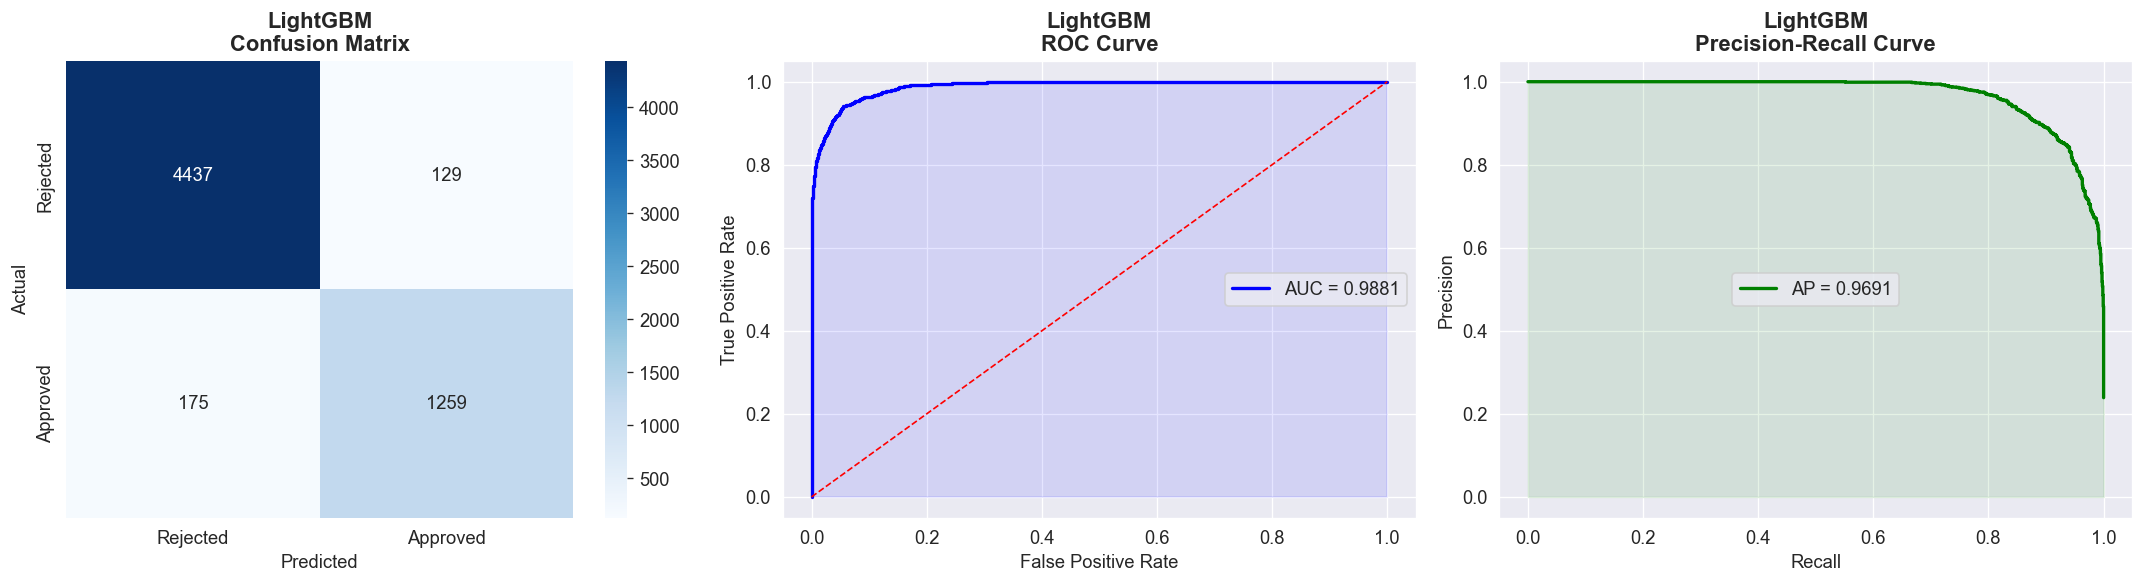


Classification Report:
              precision    recall  f1-score   support

    Rejected       0.96      0.97      0.97      4566
    Approved       0.91      0.88      0.89      1434

    accuracy                           0.95      6000
   macro avg       0.93      0.92      0.93      6000
weighted avg       0.95      0.95      0.95      6000



In [26]:
import re

# Replace any character that isn't alphanumeric or an underscore with an underscore
X_train_res = X_train_res.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', str(x)))

# Now you can safely fit your model
lgbm_grid.fit(X_train_res, y_train_res)

print('=== LightGBM Hyperparameter Tuning ===')

lgbm_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [5, 8, -1],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63],
    'min_child_samples': [20, 50],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [0, 0.1]
}

lgbm_base = LGBMClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgbm_grid = GridSearchCV(
    lgbm_base, lgbm_param_grid, cv=cv,
    scoring='roc_auc', n_jobs=-1, verbose=1, refit=True
)
lgbm_grid.fit(X_train_res, y_train_res)

print(f'\nBest Params: {lgbm_grid.best_params_}')
print(f'Best CV ROC-AUC: {lgbm_grid.best_score_:.4f}')

lgbm_best = lgbm_grid.best_estimator_
lgbm_metrics, lgbm_pred, lgbm_prob = evaluate_model(
    lgbm_best, X_train_res, y_train_res, X_test, y_test, 'LightGBM', cv
)
plot_model_evaluation('LightGBM', y_test, lgbm_pred, lgbm_prob)
print('\nClassification Report:')
print(classification_report(y_test, lgbm_pred, target_names=['Rejected', 'Approved']))

In [28]:
import re

# Apply the same renaming to the test set
X_test = X_test.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', str(x)))

# Now run your evaluation
gb_metrics, gb_pred, gb_prob = evaluate_model(
    gb_best, X_train_res, y_train_res, X_test, y_test, 'Gradient Boosting', cv
)

### 7.4 Gradient Boosting

=== Gradient Boosting Hyperparameter Tuning ===
Fitting 5 folds for each of 64 candidates, totalling 320 fits

Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300, 'subsample': 0.8}
Best CV ROC-AUC: 0.9964


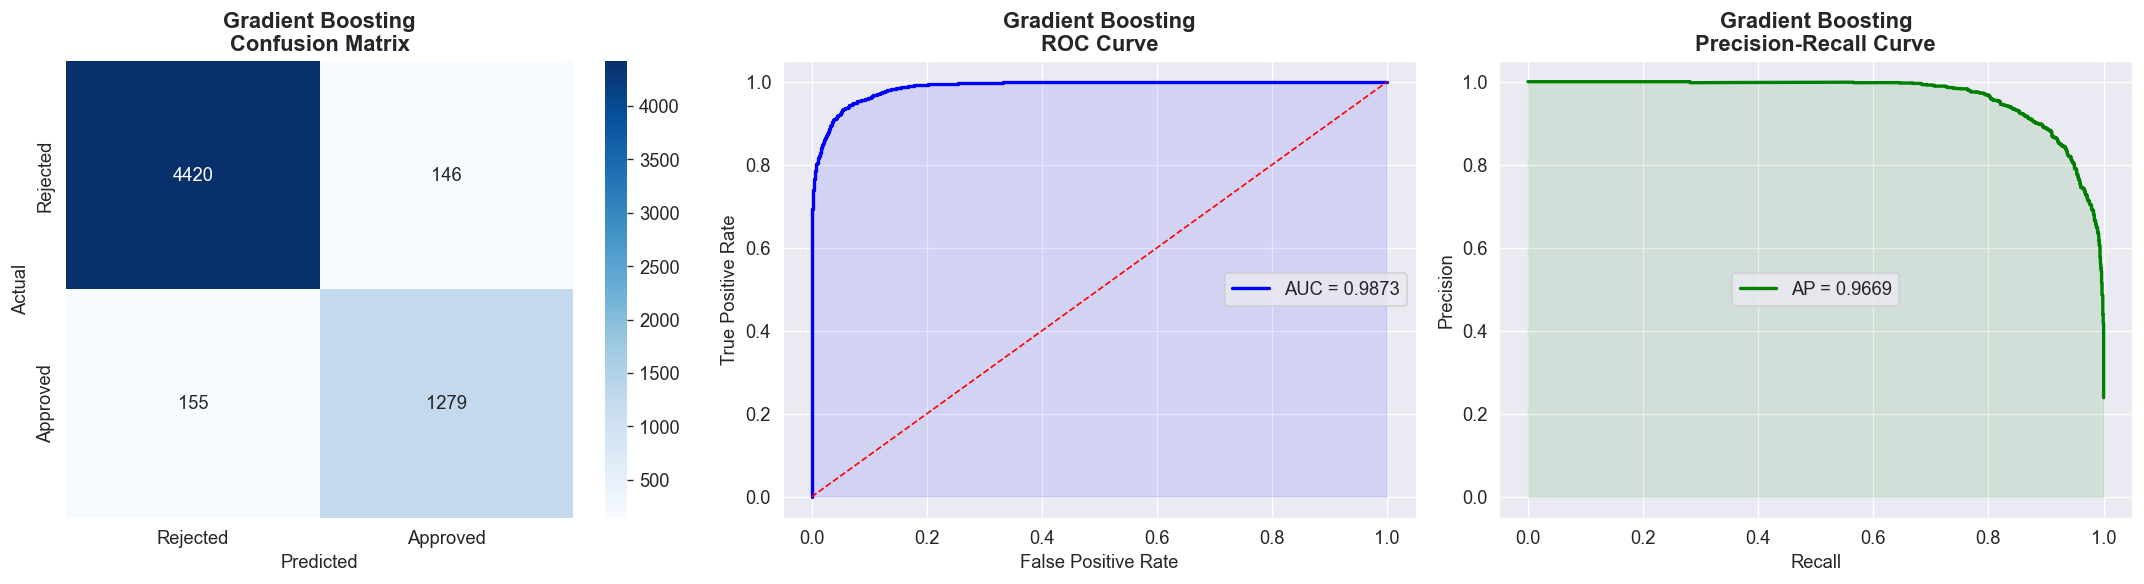


Classification Report:
              precision    recall  f1-score   support

    Rejected       0.97      0.97      0.97      4566
    Approved       0.90      0.89      0.89      1434

    accuracy                           0.95      6000
   macro avg       0.93      0.93      0.93      6000
weighted avg       0.95      0.95      0.95      6000



In [29]:
print('=== Gradient Boosting Hyperparameter Tuning ===')

gb_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', None]
}

gb_base = GradientBoostingClassifier(random_state=RANDOM_STATE)

gb_grid = GridSearchCV(
    gb_base, gb_param_grid, cv=cv,
    scoring='roc_auc', n_jobs=-1, verbose=1, refit=True
)
gb_grid.fit(X_train_res, y_train_res)

print(f'\nBest Params: {gb_grid.best_params_}')
print(f'Best CV ROC-AUC: {gb_grid.best_score_:.4f}')

gb_best = gb_grid.best_estimator_
gb_metrics, gb_pred, gb_prob = evaluate_model(
    gb_best, X_train_res, y_train_res, X_test, y_test, 'Gradient Boosting', cv
)
plot_model_evaluation('Gradient Boosting', y_test, gb_pred, gb_prob)
print('\nClassification Report:')
print(classification_report(y_test, gb_pred, target_names=['Rejected', 'Approved']))

## 8. Model Comparison

In [31]:
all_metrics = [xgb_metrics, rf_metrics, lgbm_metrics, gb_metrics]

results_df = pd.DataFrame(all_metrics)
results_df = results_df.set_index('Model')
results_df_display = results_df.round(4)

print('=== Model Comparison Table ===')
print(results_df_display.to_string())

# Save results
results_df.to_csv('/Users/muditpanwar/PycharmProjects/credit_risk_analysis_project/output/results/model_comparison_results.csv')
print('\nResults saved to model_comparison_results.csv')

=== Model Comparison Table ===
                   CV_ROC_AUC_Mean  CV_ROC_AUC_Std  CV_F1_Mean  CV_Accuracy_Mean  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  Test_ROC_AUC  Test_Avg_Precision
Model                                                                                                                                                                  
XGBoost                     0.9969          0.0002      0.9722            0.9723         0.9508          0.9048       0.8877   0.8962        0.9881              0.9693
Random Forest               0.9950          0.0005      0.9636            0.9636         0.9422          0.8836       0.8731   0.8783        0.9809              0.9528
LightGBM                    0.9971          0.0004      0.9715            0.9717         0.9493          0.9071       0.8780   0.8923        0.9881              0.9691
Gradient Boosting           0.9964          0.0002      0.9697            0.9698         0.9498          0.8975       0.8919   0.

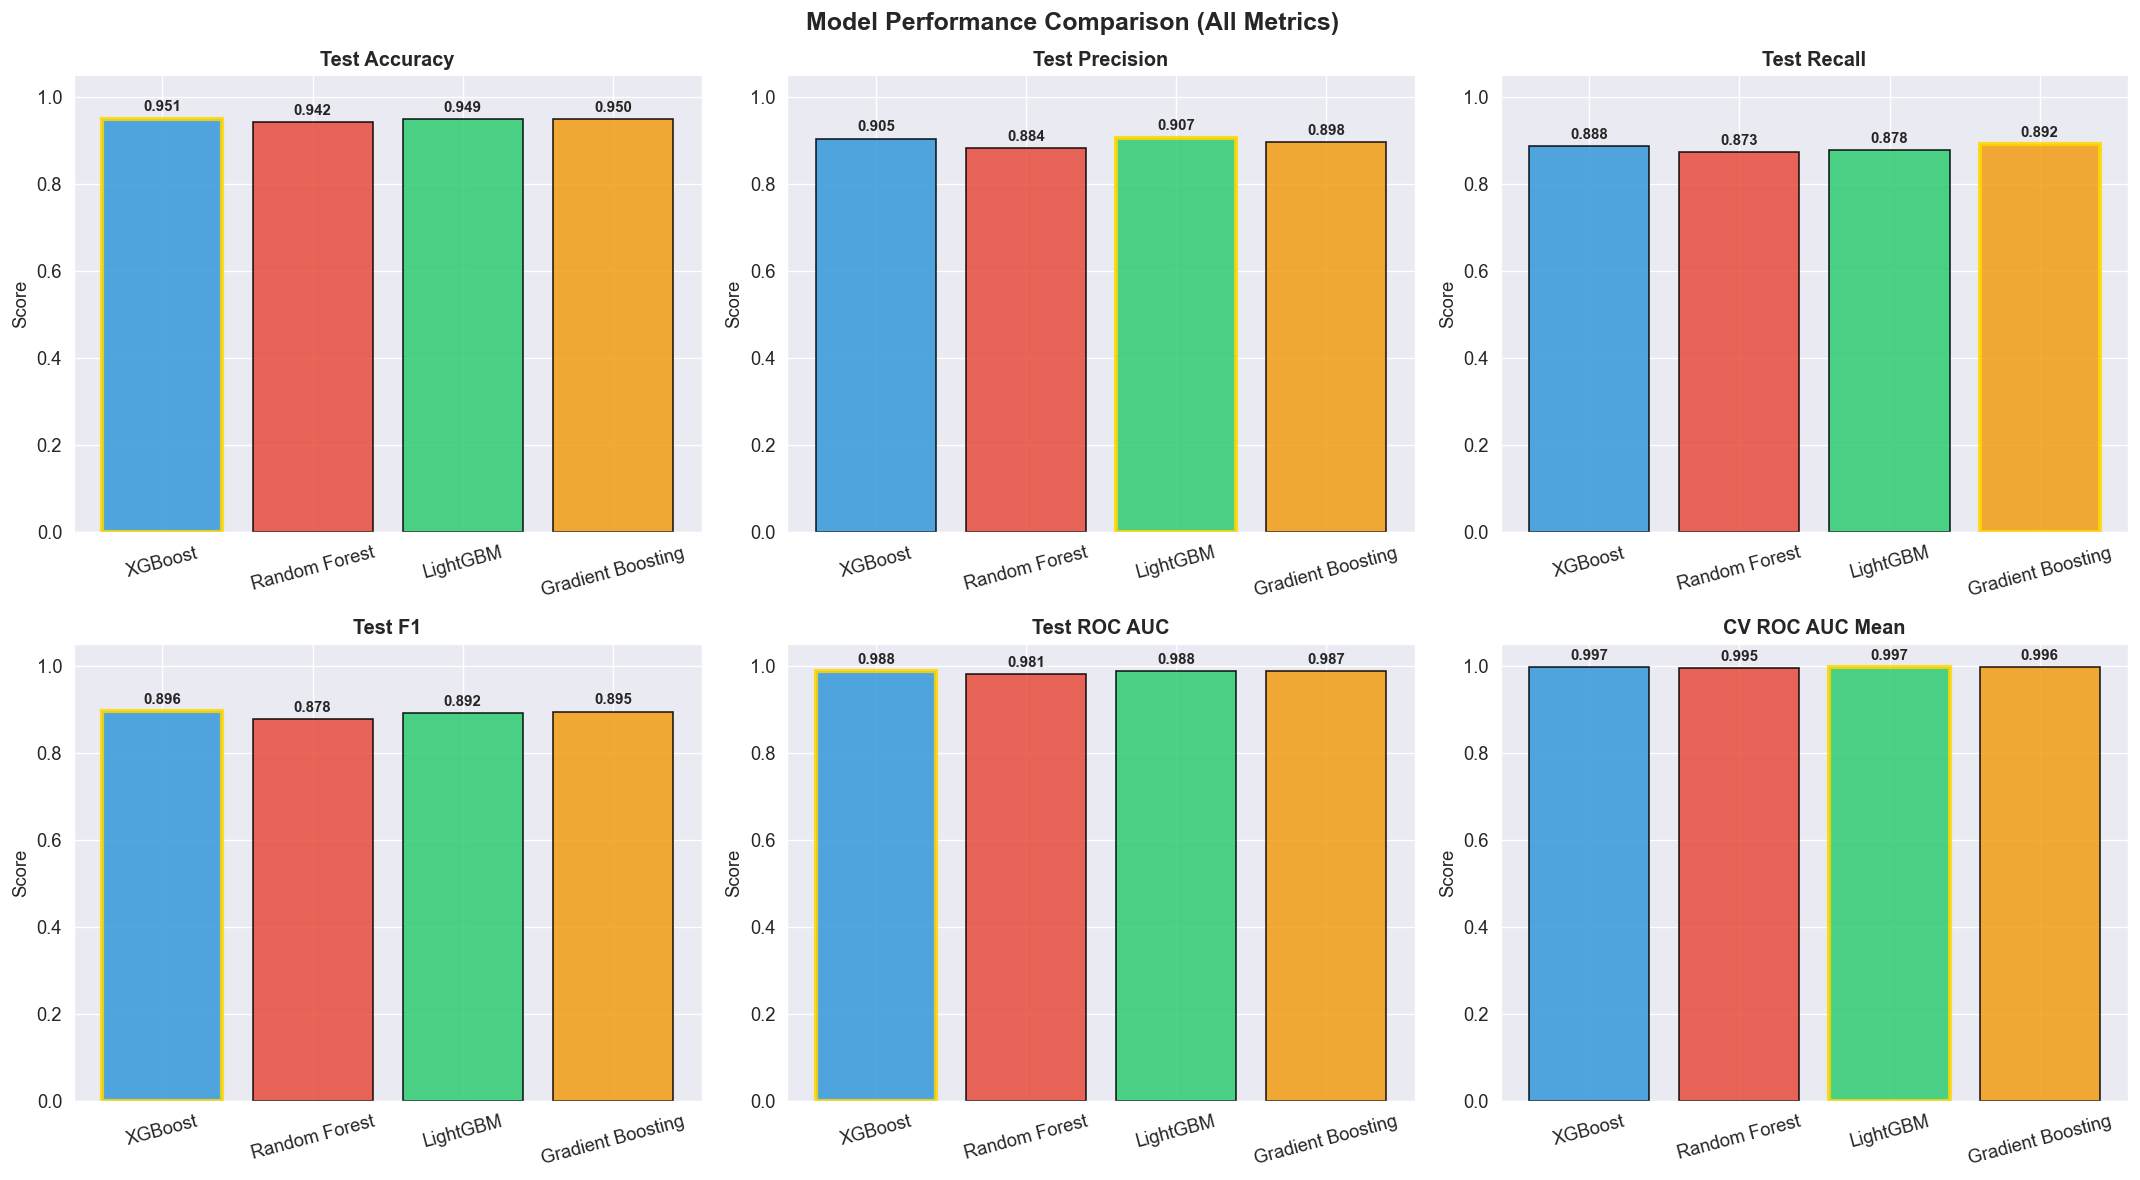

In [33]:
# Comparison bar charts
metrics_to_plot = ['Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1', 'Test_ROC_AUC', 'CV_ROC_AUC_Mean']
colors = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    vals = results_df[metric]
    bars = axes[i].bar(vals.index, vals.values, color=colors[:len(vals)], edgecolor='black', alpha=0.85)
    axes[i].set_title(metric.replace('_', ' '), fontsize=12, fontweight='bold')
    axes[i].set_ylim(0, 1.05)
    axes[i].set_ylabel('Score')
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals.values):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    # Highlight best
    best_idx = vals.values.argmax()
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)

plt.suptitle('Model Performance Comparison (All Metrics)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/muditpanwar/PycharmProjects/credit_risk_analysis_project/output/figures/model_comparison.png', bbox_inches='tight')
plt.show()

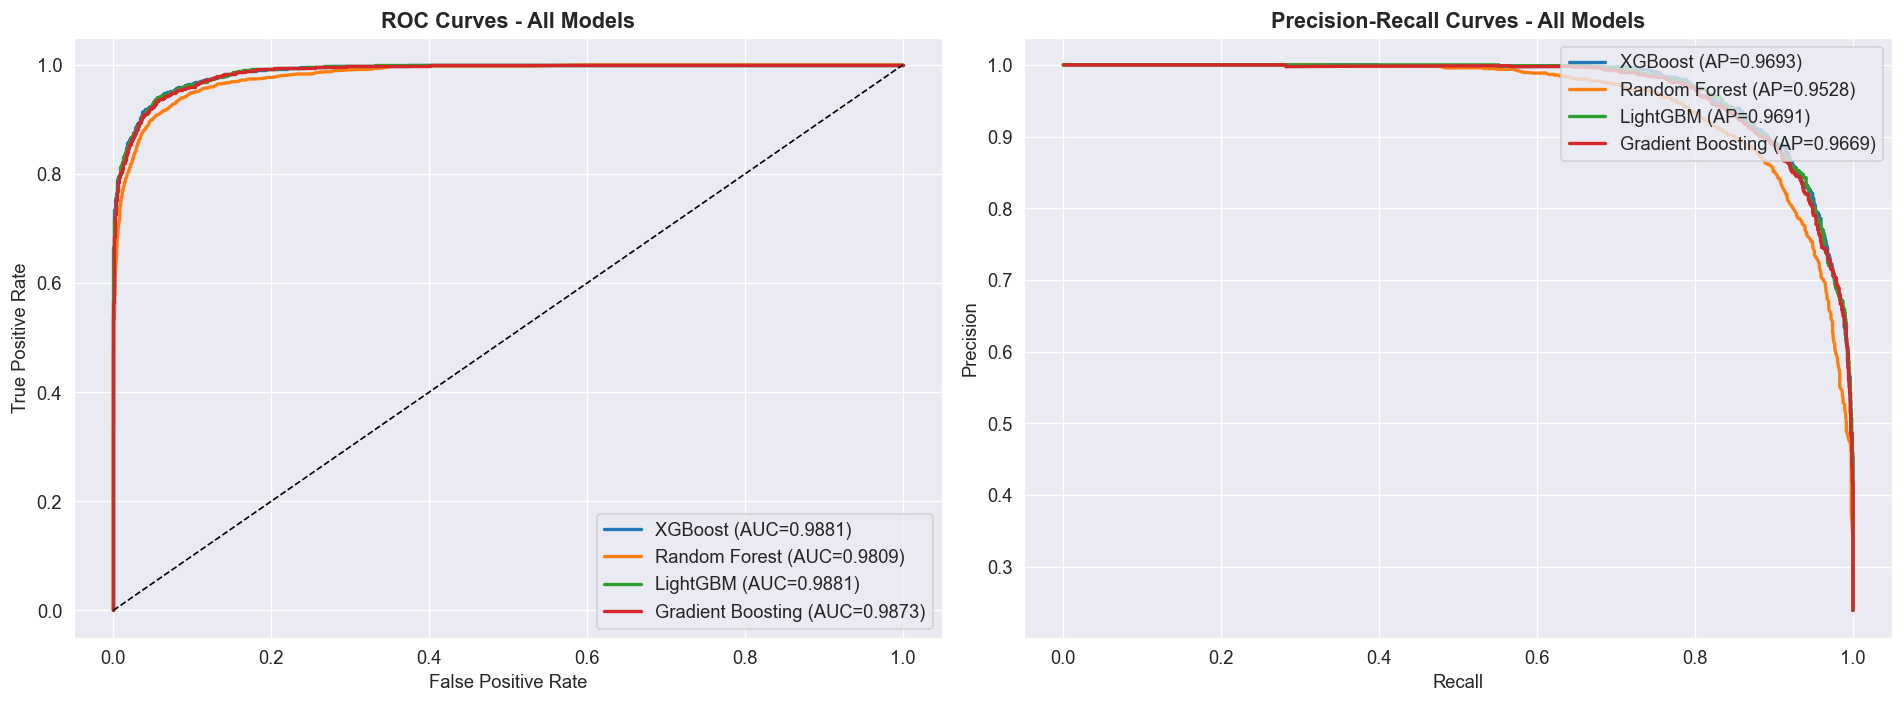

In [34]:
# ROC Curves - All models together
models_probs = {
    'XGBoost': xgb_prob,
    'Random Forest': rf_prob,
    'LightGBM': lgbm_prob,
    'Gradient Boosting': gb_prob,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for model_name, prob in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC={auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves - All Models', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')

for model_name, prob in models_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    axes[1].plot(recall, precision, linewidth=2, label=f'{model_name} (AP={ap:.4f})')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves - All Models', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('/Users/muditpanwar/PycharmProjects/credit_risk_analysis_project/output/figures/roc_pr_comparison.png', bbox_inches='tight')
plt.show()

## 9. Feature Importance

Best Model by Test ROC-AUC: XGBoost


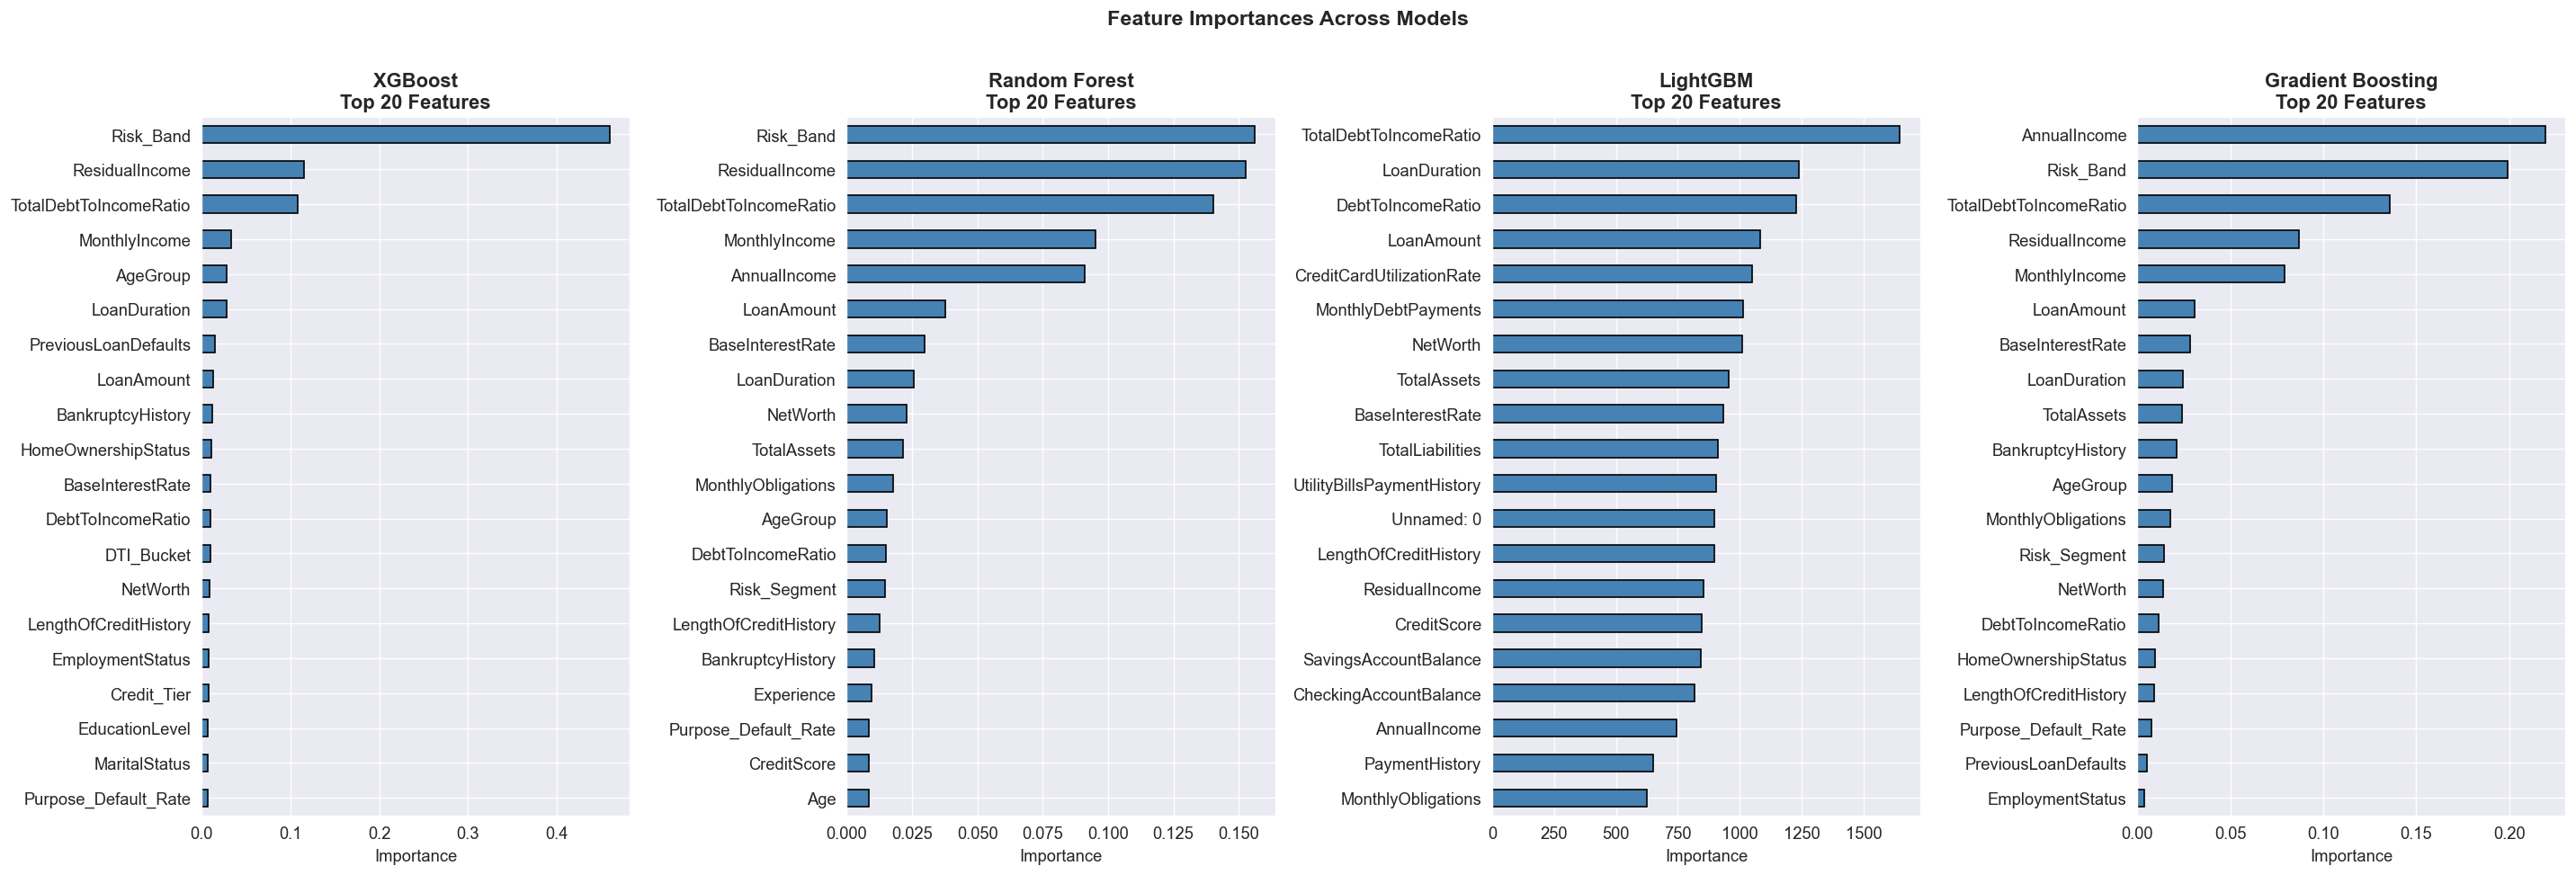

In [35]:
# Best model selection
best_model_name = results_df['Test_ROC_AUC'].idxmax()
print(f'Best Model by Test ROC-AUC: {best_model_name}')

best_model_obj = {
    'XGBoost': xgb_best,
    'Random Forest': rf_best,
    'LightGBM': lgbm_best,
    'Gradient Boosting': gb_best,
}


best_model = best_model_obj[best_model_name]

# Feature importance for each tree model
fig, axes = plt.subplots(1, len(best_model_obj), figsize=(6 * len(best_model_obj), 8))
if len(best_model_obj) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, best_model_obj.items()):
    if hasattr(model, 'feature_importances_'):
        fi = pd.Series(model.feature_importances_, index=X.columns)
        fi = fi.nlargest(20)
        fi.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
        ax.set_title(f'{name}\nTop 20 Features', fontweight='bold')
        ax.set_xlabel('Importance')

plt.suptitle('Feature Importances Across Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/Users/muditpanwar/PycharmProjects/credit_risk_analysis_project/output/figures/feature_importances.png', bbox_inches='tight')
plt.show()

## 10. Save Best Model & Artifacts

In [38]:
os.makedirs('models', exist_ok=True)

# Save all models
for name, model in best_model_obj.items():
    fname = f'models/{name.lower().replace(" ", "_")}_best.pkl'
    joblib.dump(model, fname)
    print(f'Saved: {fname}')

# Save label encoders
joblib.dump(label_encoders, 'models/label_encoders.pkl')
joblib.dump(ordinal_maps, 'models/ordinal_maps.pkl')

# Save feature columns and results
feature_cols = list(X.columns)
with open('models/feature_columns.json', 'w') as f:
    json.dump(feature_cols, f)

results_df.to_json('models/model_results.json', orient='index', indent=2)

print(f'\nBest model: {best_model_name}')
print(f'All models, encoders, and results saved to /models/')

Saved: models/xgboost_best.pkl
Saved: models/random_forest_best.pkl
Saved: models/lightgbm_best.pkl
Saved: models/gradient_boosting_best.pkl

Best model: XGBoost
All models, encoders, and results saved to /models/


## 11. Final Summary

In [39]:
print('=' * 65)
print('           CREDIT RISK MODELLING - FINAL RESULTS SUMMARY')
print('=' * 65)
print(f'Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Training samples: {X_train_res.shape[0]:,} (after SMOTE if applied)')
print(f'Test samples: {X_test.shape[0]:,}')
print(f'Feature count: {X.shape[1]}')
print(f'Cross-validation: Stratified 5-Fold')
print('-' * 65)
print('\nPERFORMANCE METRICS (Test Set):')
print(results_df[['Test_Accuracy', 'Test_F1', 'Test_ROC_AUC', 'CV_ROC_AUC_Mean', 'CV_ROC_AUC_Std']]
      .round(4).to_string())
print('-' * 65)
print(f'\n🏆 BEST MODEL: {best_model_name}')
best = results_df.loc[best_model_name]
print(f'   Test ROC-AUC:    {best["Test_ROC_AUC"]:.4f}')
print(f'   Test F1-Score:   {best["Test_F1"]:.4f}')
print(f'   Test Accuracy:   {best["Test_Accuracy"]:.4f}')
print(f'   CV ROC-AUC:      {best["CV_ROC_AUC_Mean"]:.4f} ± {best["CV_ROC_AUC_Std"]:.4f}')
print('=' * 65)

           CREDIT RISK MODELLING - FINAL RESULTS SUMMARY
Dataset: 20,000 rows × 51 columns
Training samples: 21,308 (after SMOTE if applied)
Test samples: 6,000
Feature count: 43
Cross-validation: Stratified 5-Fold
-----------------------------------------------------------------

PERFORMANCE METRICS (Test Set):
                   Test_Accuracy  Test_F1  Test_ROC_AUC  CV_ROC_AUC_Mean  CV_ROC_AUC_Std
Model                                                                                   
XGBoost                   0.9508   0.8962        0.9881           0.9969          0.0002
Random Forest             0.9422   0.8783        0.9809           0.9950          0.0005
LightGBM                  0.9493   0.8923        0.9881           0.9971          0.0004
Gradient Boosting         0.9498   0.8947        0.9873           0.9964          0.0002
-----------------------------------------------------------------

🏆 BEST MODEL: XGBoost
   Test ROC-AUC:    0.9881
   Test F1-Score:   0.8962
   Test A